# 07. Metrics Analysis: OOS Detection

Консолидированный анализ результатов OOS-детекции на базе
`results/metrics.json` с фокусом на сравнении фреймворков,
датасетов и few-shot режимов относительно AutoIntent-бейзлайна.

## Содержание
1. Setup
2. Покрытие экспериментов
3. Сравнение по фреймворкам
4. Сравнение по датасетам
5. Сравнение по шотам
6. AutoIntent vs лучшие альтернативы
7. Аналитика в стиле `06_results_summary`
8. Выводы и рекомендации

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

# Ноутбук лежит в autoguardrails_oos_detection/tasks/oos_detection/notebooks
METRICS_PATH = Path('../results/metrics.json')

with METRICS_PATH.open('r', encoding='utf-8') as f:
    doc = json.load(f)

main_metrics = doc['content']['main_metrics']
df = pd.json_normalize(main_metrics)

# Нормализуем часто используемые поля.
df['source'] = df.get('extra.source')
df['framework'] = df.get('extra.framework').fillna('classic')
df['shots'] = df['n_shots'].fillna(0).astype(int)

df.head(3)

,model_name,mode,oos_recall,in_domain_acc,f1_oos,auroc,au_ioc,latency_ms,n_shots,seed,is_reference,extra.source,extra.preset,extra.embedder,extra.embedder_fixed,extra.pilot,extra.comparable_to_table3,extra.model_dir,extra.framework,source,framework,shots
0,tfidf_argmax,full,0.125,0.889333,0.220070,0.871902,0.785160,1.491169,NaN,NaN,False,standard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,standard,classic,0
1,tfidf_threshold,full,0.322,0.873333,0.447844,0.871902,0.780725,3.062148,NaN,NaN,False,standard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,standard,classic,0
2,cosine_bert_argmax,full,0.846,0.695556,0.601493,0.897658,0.676596,14.413166,NaN,NaN,False,standard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,standard,classic,0


## 1. Setup

In [2]:
coverage = (
    df.groupby(['framework', 'source', 'mode'], dropna=False)
      .size()
      .rename('runs')
      .reset_index()
      .sort_values(['framework', 'source', 'mode'])
)
coverage

,framework,source,mode,runs
0,autogluon,deeppavlov,10shot,3
1,autogluon,deeppavlov,20shot,3
2,autogluon,deeppavlov,50shot,3
3,autogluon,deeppavlov,full,1
4,autogluon,standard,10shot,3
5,autogluon,standard,20shot,3
6,autogluon,standard,50shot,3
7,autogluon,standard,full,1
8,classic,deeppavlov,10shot,30
9,classic,deeppavlov,20shot,30


## 2. Покрытие экспериментов

Проверяем, что в консолидированном `metrics.json` есть ожидаемые комбинации
`framework × source × mode`.

In [3]:
metric_cols = ['f1_oos', 'oos_recall', 'in_domain_acc', 'auroc']

framework_cmp = (
    df.groupby('framework', dropna=False)[metric_cols]
      .agg(['mean', 'median', 'max'])
      .round(4)
)
framework_cmp

f1_oos                 oos_recall                in_domain_acc                   auroc                
             mean  median     max       mean  median    max          mean  median     max    mean  median     max
framework                                                                                                        
autogluon  0.6362  0.6695  0.7247     0.5652  0.5925  0.674        0.8700  0.8753  0.9282  0.9326  0.9295  0.9619
classic    0.4740  0.4363  0.8202     0.4948  0.5345  0.999        0.7631  0.8529  0.9598  0.9059  0.9469  0.9741
h2o        0.6876  0.7113  0.7749     0.6118  0.5870  1.000        0.9015  0.9440  0.9673  0.9383  0.9623  0.9684
lama       0.6683  0.6683  0.6683     0.5370  0.5370  0.537        0.9324  0.9324  0.9324  0.9518  0.9518  0.9518

## 3. Сравнение по фреймворкам

Агрегаты по ключевым метрикам: `f1_oos`, `oos_recall`, `in_domain_acc`, `auroc`.

In [4]:
dataset_cmp = (
    df.groupby(['source', 'framework'], dropna=False)[metric_cols]
      .mean()
      .round(4)
      .sort_values(['source', 'f1_oos'], ascending=[True, False])
)
dataset_cmp

f1_oos  oos_recall  in_domain_acc   auroc
source     framework                                           
deeppavlov h2o        0.6676      0.6332         0.8532  0.9149
           autogluon  0.6161      0.5430         0.8736  0.9318
           classic    0.4802      0.5043         0.7623  0.9071
standard   h2o        0.7075      0.5903         0.9499  0.9617
           lama       0.6683      0.5370         0.9324  0.9518
           autogluon  0.6563      0.5875         0.8664  0.9335
           classic    0.4677      0.4852         0.7639  0.9046

## 4. Сравнение по датасетам (`standard` vs `deeppavlov`)

Смотрим усреднённые метрики по каждому фреймворку отдельно для каждого source.

In [5]:
shots_cmp = (
    df.groupby(['mode', 'framework'], dropna=False)[metric_cols]
      .mean()
      .round(4)
      .sort_values(['mode', 'f1_oos'], ascending=[True, False])
)
shots_cmp

f1_oos  oos_recall  in_domain_acc   auroc
mode   framework                                           
10shot lama       0.6683      0.5370         0.9324  0.9518
       autogluon  0.6341      0.5252         0.8640  0.9461
       h2o        0.6307      0.4850         0.9366  0.9549
       classic    0.4628      0.5077         0.7019  0.8844
20shot h2o        0.7473      0.6547         0.9464  0.9616
       autogluon  0.6182      0.5558         0.8405  0.9231
       classic    0.4683      0.5000         0.7553  0.9017
50shot h2o        0.7449      0.6377         0.9609  0.9665
       autogluon  0.6497      0.5990         0.8875  0.9284
       classic    0.4798      0.4790         0.8080  0.9223
full   autogluon  0.6561      0.6125         0.9239  0.9338
       classic    0.5073      0.4878         0.8355  0.9336
       h2o        0.5070      0.7855         0.4837  0.7342

## 5. Сравнение по шотам

`full` рассматривается отдельно от few-shot режимов (`10/20/50-shot`).

In [6]:
AUTOINTENT_MODELS = {
    'autointent_classic-light',
    'autointent_classic-light_autoembedder',
}

base = df[df['model_name'].isin(AUTOINTENT_MODELS)].copy()
other = df[~df['model_name'].isin(AUTOINTENT_MODELS)].copy()

# Лучшая модель среди AutoIntent по каждому source/mode.
base_best = (
    base.sort_values('f1_oos', ascending=False)
        .groupby(['source', 'mode'], as_index=False)
        .first()[['source', 'mode', 'model_name', 'f1_oos', 'oos_recall', 'in_domain_acc', 'auroc']]
        .rename(columns={
            'model_name': 'autointent_model',
            'f1_oos': 'autointent_f1',
            'oos_recall': 'autointent_oos_recall',
            'in_domain_acc': 'autointent_in_domain_acc',
            'auroc': 'autointent_auroc',
        })
)

# Лучшая небейзлайновая модель по каждому source/mode.
other_best = (
    other.sort_values('f1_oos', ascending=False)
         .groupby(['source', 'mode'], as_index=False)
         .first()[['source', 'mode', 'model_name', 'f1_oos', 'oos_recall', 'in_domain_acc', 'auroc']]
         .rename(columns={
             'model_name': 'best_non_autointent_model',
             'f1_oos': 'best_non_autointent_f1',
             'oos_recall': 'best_non_autointent_oos_recall',
             'in_domain_acc': 'best_non_autointent_in_domain_acc',
             'auroc': 'best_non_autointent_auroc',
         })
)

auto_vs_best = base_best.merge(other_best, on=['source', 'mode'], how='inner')
auto_vs_best['delta_f1'] = (auto_vs_best['autointent_f1'] - auto_vs_best['best_non_autointent_f1']).round(4)
auto_vs_best['delta_oos_recall'] = (auto_vs_best['autointent_oos_recall'] - auto_vs_best['best_non_autointent_oos_recall']).round(4)
auto_vs_best['delta_in_domain_acc'] = (auto_vs_best['autointent_in_domain_acc'] - auto_vs_best['best_non_autointent_in_domain_acc']).round(4)

auto_vs_best = auto_vs_best.sort_values(['source', 'mode'])
auto_vs_best

,source,mode,autointent_model,autointent_f1,autointent_oos_recall,autointent_in_domain_acc,autointent_auroc,best_non_autointent_model,best_non_autointent_f1,best_non_autointent_oos_recall,best_non_autointent_in_domain_acc,best_non_autointent_auroc,delta_f1,delta_oos_recall,delta_in_domain_acc
0,deeppavlov,10shot,autointent_classic-light_autoembedder,0.782226,0.889,0.874667,0.961892,autogluon_threshold,0.705743,0.596,0.877556,0.959690,0.0765,0.293,-0.0029
1,deeppavlov,20shot,autointent_classic-light,0.820202,0.812,0.921556,0.969264,h2o_threshold,0.774892,0.716,0.942222,0.962320,0.0453,0.096,-0.0207
2,deeppavlov,50shot,autointent_classic-light,0.734743,0.608,0.959333,0.971657,h2o_threshold,0.760931,0.670,0.956444,0.965919,-0.0262,-0.062,0.0029
3,deeppavlov,full,autointent_classic-light,0.703379,0.562,0.958667,0.974127,cosine_e5large_threshold,0.722122,0.599,0.907111,0.961069,-0.0187,-0.037,0.0516
4,standard,10shot,autointent_classic-light,0.751281,0.660,0.921778,0.960983,autogluon_threshold,0.724654,0.629,0.883111,0.961893,0.0266,0.031,0.0387
5,standard,20shot,autointent_classic-light_autoembedder,0.790698,0.714,0.942889,0.969285,h2o_threshold,0.774892,0.716,0.942222,0.962320,0.0158,-0.002,0.0007
6,standard,50shot,autointent_classic-light_autoembedder,0.735632,0.608,0.959778,0.972810,h2o_threshold,0.760931,0.670,0.956444,0.965919,-0.0253,-0.062,0.0033
7,standard,full,autointent_classic-light,0.698871,0.557,0.957778,0.973483,cosine_e5large_threshold,0.722122,0.599,0.907111,0.961069,-0.0233,-0.042,0.0507


In [7]:
# Где AutoIntent выигрывает/проигрывает по F1_OOS
wins = (auto_vs_best['delta_f1'] > 0).sum()
losses = (auto_vs_best['delta_f1'] < 0).sum()
ties = (auto_vs_best['delta_f1'] == 0).sum()

summary = pd.DataFrame([
    {'metric': 'wins_by_f1', 'value': int(wins)},
    {'metric': 'losses_by_f1', 'value': int(losses)},
    {'metric': 'ties_by_f1', 'value': int(ties)},
    {'metric': 'mean_delta_f1', 'value': round(float(auto_vs_best['delta_f1'].mean()), 4)},
    {'metric': 'median_delta_f1', 'value': round(float(auto_vs_best['delta_f1'].median()), 4)},
])
summary

,metric,value
0,wins_by_f1,4.0000
1,losses_by_f1,4.0000
2,ties_by_f1,0.0000
3,mean_delta_f1,0.0088
4,median_delta_f1,-0.0014


## 6. AutoIntent vs лучшие альтернативы

Бейзлайн: `autointent_classic-light` и `autointent_classic-light_autoembedder`.
Сравнение ведётся с лучшей небейзлайновой моделью для каждого `source × mode`.

In [8]:
# Удалён дублирующий блок автовыводов: выводы собраны в секции 8.

## 7. Сводные таблицы и scaling curve

Ключевые срезы в формате `06_results_summary`: таблицы по source, few-shot summary и scaling curve.

In [9]:
# Модели для сопоставимого summary (как в 06)
models_order = [
    'autointent_classic-light',
    'cosine_e5large_threshold',
    'cosine_minilm_threshold',
    'tfidf_threshold',
]

print('=== Записей по source ===')
print(df.groupby('source').size())
print()

print('=== F1 OOS (mean ± std) по моделям и source ===')
summary_06_style = (
    df[df['model_name'].isin(models_order)]
      .groupby(['model_name', 'source'])['f1_oos']
      .agg(['mean', 'std'])
      .round(4)
)
display(summary_06_style.unstack('source'))

=== Записей по source ===
source
deeppavlov    120
standard      121
dtype: int64

=== F1 OOS (mean ± std) по моделям и source ===


mean                 std         
source                   deeppavlov standard deeppavlov standard
model_name                                                      
autointent_classic-light     0.7558   0.7266     0.0340   0.0452
cosine_e5large_threshold     0.6717   0.6717     0.0365   0.0365
cosine_minilm_threshold      0.6601   0.6601     0.0294   0.0294
tfidf_threshold              0.2946   0.2267     0.0689   0.1090

In [10]:
# Full train сравнение по source (похожий табличный формат)
df_full = df[(df['mode'] == 'full') & (df['model_name'].isin(models_order))].copy()

for source in ['deeppavlov', 'standard']:
    print(f'--- {source.upper()} / full ---')
    source_df = df_full[df_full['source'] == source].copy()
    source_df['sort_key'] = source_df['model_name'].apply(lambda x: models_order.index(x) if x in models_order else 999)
    source_df = source_df.sort_values('sort_key')

    cols = ['model_name', 'oos_recall', 'in_domain_acc', 'f1_oos', 'auroc', 'latency_ms']
    table = source_df[cols].copy()
    table.columns = ['Model', 'OOS Recall', 'In-D Acc', 'F1 OOS', 'AUROC', 'Lat(ms)']

    for col in ['OOS Recall', 'In-D Acc', 'F1 OOS', 'AUROC']:
        table[col] = table[col].map(lambda x: f'{x:.3f}')
    table['Lat(ms)'] = table['Lat(ms)'].map(lambda x: f'{x:.2f}')

    display(table)
    print()

--- DEEPPAVLOV / full ---


,Model,OOS Recall,In-D Acc,F1 OOS,AUROC,Lat(ms)
170,autointent_classic-light,0.562,0.959,0.703,0.974,28.49
87,cosine_e5large_threshold,0.599,0.907,0.722,0.961,19.25
85,cosine_minilm_threshold,0.500,0.874,0.647,0.963,6.99
81,tfidf_threshold,0.284,0.876,0.408,0.874,2.92



--- STANDARD / full ---


,Model,OOS Recall,In-D Acc,F1 OOS,AUROC,Lat(ms)
160,autointent_classic-light,0.557,0.958,0.699,0.973,0.20
7,cosine_e5large_threshold,0.599,0.907,0.722,0.961,18.98
5,cosine_minilm_threshold,0.500,0.874,0.647,0.963,6.98
1,tfidf_threshold,0.322,0.873,0.448,0.872,3.06


In [11]:
# Few-shot summary для deeppavlov (сопоставимо с Table 3)
df_dp = df[df['source'] == 'deeppavlov']
n_shots_values = [10, 20, 50]

fewshot_rows = []
for model in models_order:
    row = {'Model': model}
    for n in n_shots_values:
        subset = df_dp[(df_dp['model_name'] == model) & (df_dp['n_shots'] == n)]
        if len(subset) > 0:
            mean = subset['f1_oos'].mean()
            std = subset['f1_oos'].std() if len(subset) > 1 else 0.0
            row[f'{n}-shot'] = f'{mean:.3f} ± {std:.3f}' if std > 0 else f'{mean:.3f}'
        else:
            row[f'{n}-shot'] = '—'
    fewshot_rows.append(row)

fewshot_summary = pd.DataFrame(fewshot_rows)
print('F1 OOS by model and n_shots (deeppavlov, mean ± std across seeds)')
display(fewshot_summary)

F1 OOS by model and n_shots (deeppavlov, mean ± std across seeds)


,Model,10-shot,20-shot,50-shot
0,autointent_classic-light,0.763 ± 0.017,0.790 ± 0.030,0.732 ± 0.003
1,cosine_e5large_threshold,0.651 ± 0.030,0.694 ± 0.034,0.654 ± 0.029
2,cosine_minilm_threshold,0.662 ± 0.024,0.638 ± 0.039,0.685 ± 0.007
3,tfidf_threshold,0.257 ± 0.010,0.242 ± 0.064,0.347 ± 0.019


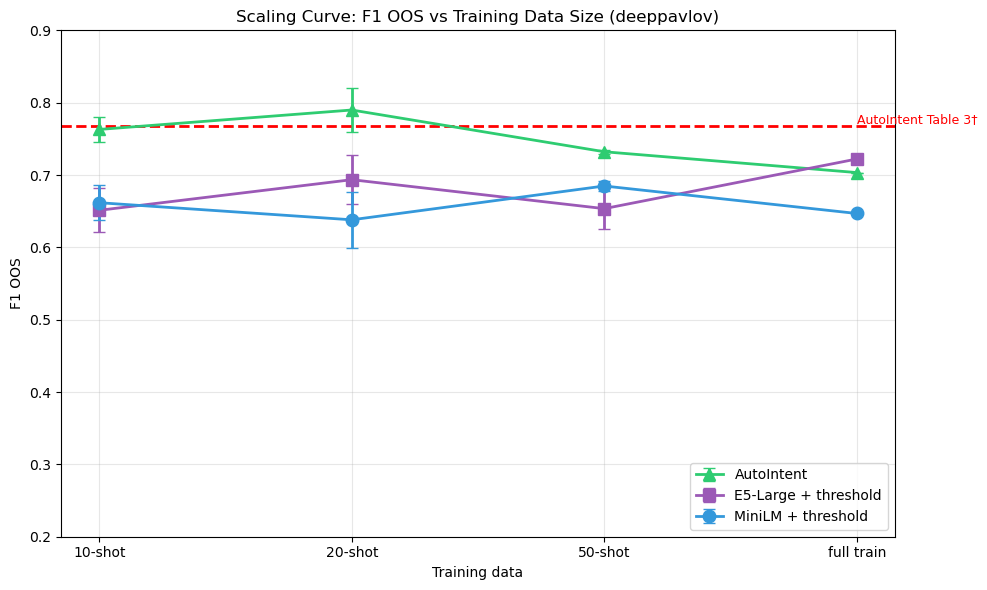

In [12]:
# Scaling curve (deeppavlov): AutoIntent vs cosine baselines
import matplotlib.pyplot as plt

scaling_models = [
    'autointent_classic-light',
    'cosine_e5large_threshold',
    'cosine_minilm_threshold',
]

scaling_data = []
for model in scaling_models:
    model_df = df_dp[df_dp['model_name'] == model]
    for n in [10, 20, 50]:
        subset = model_df[model_df['n_shots'] == n]
        if len(subset) > 0:
            scaling_data.append({
                'model': model,
                'mode': f'{n}-shot',
                'f1_oos_mean': subset['f1_oos'].mean(),
                'f1_oos_std': subset['f1_oos'].std() if len(subset) > 1 else 0.0,
            })
    full_subset = model_df[model_df['mode'] == 'full']
    if len(full_subset) > 0:
        scaling_data.append({
            'model': model,
            'mode': 'full train',
            'f1_oos_mean': full_subset['f1_oos'].iloc[0],
            'f1_oos_std': 0.0,
        })

scaling_df = pd.DataFrame(scaling_data)

fig, ax = plt.subplots(figsize=(10, 6))
x_labels = ['10-shot', '20-shot', '50-shot', 'full train']
x_pos = np.arange(len(x_labels))

styles = {
    'autointent_classic-light': {'color': '#2ecc71', 'marker': '^', 'label': 'AutoIntent'},
    'cosine_e5large_threshold': {'color': '#9b59b6', 'marker': 's', 'label': 'E5-Large + threshold'},
    'cosine_minilm_threshold': {'color': '#3498db', 'marker': 'o', 'label': 'MiniLM + threshold'},
}

for model in scaling_models:
    model_data = scaling_df[scaling_df['model'] == model]
    y_vals, y_errs = [], []
    for mode in x_labels:
        row = model_data[model_data['mode'] == mode]
        if len(row) > 0:
            y_vals.append(row['f1_oos_mean'].iloc[0])
            y_errs.append(row['f1_oos_std'].iloc[0])
        else:
            y_vals.append(np.nan)
            y_errs.append(0.0)
    s = styles[model]
    ax.errorbar(x_pos, y_vals, yerr=y_errs, marker=s['marker'], markersize=9, color=s['color'], linewidth=2, capsize=4, label=s['label'])

ref_f1 = 0.768
ax.axhline(y=ref_f1, color='red', linestyle='--', linewidth=2)
ax.annotate('AutoIntent Table 3†', xy=(3.0, ref_f1), fontsize=9, color='red', va='bottom')

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Training data')
ax.set_ylabel('F1 OOS')
ax.set_title('Scaling Curve: F1 OOS vs Training Data Size (deeppavlov)')
ax.set_ylim(0.2, 0.9)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Выводы и рекомендации

### Главные наблюдения

- **AutoIntent конкурентоспособен в few-shot**, особенно на `10/20-shot`, но не доминирует во всех режимах.
- **На `50-shot` усиливается конкуренция**, и в части конфигураций лучше выглядят H2O-подходы.
- **Выводы согласуются с `06_results_summary`**: для сравнения с Table 3 основным остаётся срез `deeppavlov`.

### Рекомендации

- Для отчётности по AutoIntent использовать `deeppavlov`-срез как референс.
- Для production-guardrail смотреть не только на `f1_oos`, но и на баланс `oos_recall`/`in_domain_acc`.
- При выборе модели учитывать shot-зависимость: `10/20-shot` и `50-shot` могут иметь разные лидеры.